In [ ]:
# Подключение локальной библиотеки src/rsdocs
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd() / "src"))

from src.rsdocs import data, metrics, infer, compare
from src.rsdocs.prompts import OCRPrompts, TextBBoxPrompts



### Qwen3-VL (8B) — Vision finetuning on synthetic docs

Этот ноутбук опубликован под лицензией. Используются открытые библиотеки (Unsloth, Transformers и др.)

- **Цель**: дообучить vision LLM на синтетических документах (PNG + текст), затем провести инференс и валидацию с метриками (EM, CER) и графиками.
- **Данные**: изображения и JSON лежат в каталоге `out/` репозитория (см. `*.png` + `*.json`).
- **Результаты**: сохраняются адаптеры LoRA, CSV с предсказаниями, графики отображаются в ноутбуке.



In [7]:
%%capture
# Установка (если требуется). Можно пропустить, если окружение уже готово.
import os, re
if "COLAB_" in "".join(os.environ.keys()):
    import torch
    v = re.match(r"[0-9\.]{3,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.32.post2" if v == "2.8.0" else "0.0.29.post3")
    %pip install --quiet --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    %pip install --quiet sentencepiece protobuf "datasets>=3.4.1,<4.0.0" "huggingface_hub>=0.34.0" hf_transfer
    %pip install --quiet --no-deps unsloth
%pip install --quiet transformers
%pip install --quiet --no-deps trl
%pip install --quiet pillow matplotlib



In [8]:
from unsloth import FastVisionModel
import torch

MODEL_NAME = "unsloth/Qwen3-VL-8B-Instruct-unsloth-bnb-4bit"

model, tokenizer = FastVisionModel.from_pretrained(
    MODEL_NAME,
    load_in_4bit = True,
    use_gradient_checkpointing = "unsloth",
    device_map = "balanced",
)
print("Model and tokenizer loaded.")



==((====))==  Unsloth 2025.10.12: Fast Qwen3_Vl patching. Transformers: 4.57.1. vLLM: 0.8.5.post1.
   \\   /|    NVIDIA GeForce RTX 3090 Ti. Num GPUs = 2. Max memory: 23.555 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.6. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.14it/s]


Model and tokenizer loaded.


In [9]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,
    r = 16,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)
print("PEFT (LoRA) configured.")



PEFT (LoRA) configured.


In [10]:
import os, json, glob
from PIL import Image

OUT_DIR = "/home/user/workspace/re-synthetic-docs/data"

def load_syntheticdocs(out_dir: str = OUT_DIR, max_samples: int | None = None, max_chars: int = 4000):
    data = []
    for jpath in sorted(glob.glob(os.path.join(out_dir, "*.json"))):
        try:
            with open(jpath, "r", encoding="utf-8") as f:
                meta = json.load(f)
            text = (meta.get("text") or "").strip()
            if not text:
                continue
            if len(text) > max_chars:
                text = text[:max_chars]
            stem = os.path.splitext(os.path.basename(jpath))[0]
            ppath = os.path.join(out_dir, stem + ".png")
            if not os.path.exists(ppath):
                continue
            img = Image.open(ppath).convert("RGB")
            data.append({"image": img, "text": text, "id": stem, "type": meta.get("type")})
            if max_samples and len(data) >= max_samples:
                break
        except Exception:
            continue
    return data

# Загружаем синтетические документы
dataset = load_syntheticdocs()
print(f"Loaded samples: {len(dataset)}")



Loaded samples: 110


In [11]:
instruction = "Прочитай текст документа на изображении и выведи полностью."

def convert_to_conversation(sample):
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "text",  "text": instruction},
                {"type": "image", "image": sample["image"]},
            ],
        },
        {
            "role": "assistant",
            "content": [
                {"type": "text",  "text": sample["text"]},
            ],
        },
    ]
    return {"messages": conversation}

converted_dataset = [convert_to_conversation(sample) for sample in dataset]
print("Converted dataset ready.")



Converted dataset ready.


In [12]:
from transformers import TextStreamer

FastVisionModel.for_inference(model)

sample_idx = 2 if len(dataset) > 2 else 0
image = dataset[sample_idx]["image"]

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction},
    ]}
]

input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt",
).to("cuda")

streamer = TextStreamer(tokenizer, skip_prompt=True)
_ = model.generate(
    **inputs,
    streamer=streamer,
    max_new_tokens=128,
    use_cache=True,
    temperature=1.5,
    min_p=0.1,
)



**Пресс-релиз № 56/072/86/42**

**Статус:** Закрыто  
**Дата публикации:** 09.09.2025

---

**ООО «Филатов, Логинова и Чернов»**  
**Тема:** Согласование договора

**Согласно договору № 520 от 05.02.2025, оборудование должно прибыть в срок.**

В рамках выполнения условий договора №


In [13]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model)

data_collator = UnslothVisionDataCollator(model, tokenizer)

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = data_collator,
    train_dataset = converted_dataset,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 30,                # Для быстрого прогона; замените на num_train_epochs=1 для полноценного
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "models/outputs",
        report_to = "none",
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)
print("Trainer is ready.")



Unsloth: Model does not have a default image size - using 512
Trainer is ready.


In [14]:
# Запуск обучения
trainer_stats = trainer.train()
print("Training done.")



The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 2
   \\   /|    Num examples = 110 | Num Epochs = 3 | Total steps = 30
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 51,346,944 of 8,818,470,640 (0.58% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,0.099000
2,0.100500
3,0.102300
4,0.088700
5,0.088900
6,0.082400
7,0.081400
8,0.073700
9,0.046100
10,0.052900


Training done.


In [15]:
# Память/время
gpu_stats = torch.cuda.get_device_properties(0)
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"Peak reserved memory = {used_memory} GB ({used_percentage}%).")
print(f"{trainer_stats.metrics.get('train_runtime', 'N/A')} seconds used for training.")



GPU = NVIDIA GeForce RTX 3090 Ti. Max memory = 23.555 GB.
Peak reserved memory = 2.791 GB (11.849%).
287.6136 seconds used for training.


### Evaluation and plots
Валидация модели, метрики (EM, CER), графики и экспорт CSV.



**Служебная записка № 16/972/59/11**  
**Статус**: Открыто

Организация: ОАО «Наумов, Емельянов и Белозерова»  
Подразделение/Направление: Контроль и диагностика в транспортных системах (авиа)

Даты:  
Приёмка: 27.09.2025  
Отправка: 02.10.2025  

А
**Коммерческое предложение № 95/496/36/92**  
**Статус**: Закрыто  

**Компания**: НПО «Быков»  
**Направление**: Контроль и диагностика в транспортных системах (авиация, автомо...  
**Дата**: 11.10.2025  

**Контакты**: п. Кинешма, бул. Саратовский, д. 727, 11
**Вот пример **счёта-фактуры** в бухгалтерском стиле, соответствующий вашему описанию.**

---

**СЧЁТ-ФАКТУРА**

**№ 42/119/99/51**  
**Статус:** Открыто  

**Поставщик:**  
**Групп Евдокимов**  
Адрес: с. Азов (Рост.), ул. Курская, д. 7/4 стр. 14, 429
**ДОГОВОР АРЕНДЫ № 73/970/11/10**  
**СТАТУС: ЗАКРЫТО**  

г. Москва  
"____" __________ 2025 г.  

**Арендодатель**:  
Закрытое акционерное общество «Шашков Лапин» (далее — Арендодатель),  
ИНН 771303820912, ОГРН 112774675721
**СЧЁТ-Ф

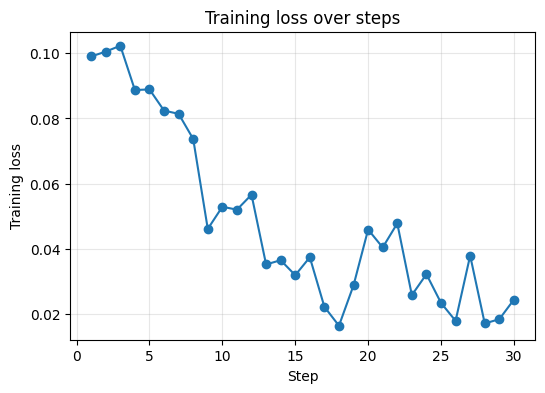

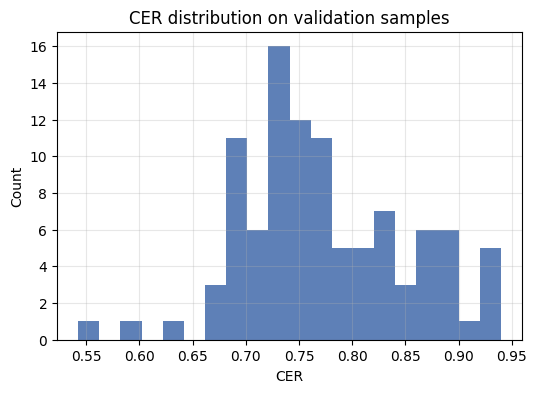

Best examples:
id=cfb43ed784524b1ba1024e65a98c024b cer=0.543 em=0


<IPython.core.display.Math object>

<IPython.core.display.Math object>

id=42ff630ddc134e2aa20125a233edac86 cer=0.596 em=0


<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

id=d778358b29eb4a36a16be7ce773a6fa5 cer=0.940 em=0


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [16]:
import re, math, csv, random
import matplotlib.pyplot as plt
from typing import List, Dict

try:
    FastVisionModel.for_inference(model)
except Exception:
    pass

if 'model' not in globals() or 'tokenizer' not in globals() or 'dataset' not in globals():
    print("Модель/токенизатор/датасет ещё не загружены. Запустите ячейки загрузки и обучения.")
else:
    def normalize_text(s: str) -> str:
        s = s.strip()
        s = re.sub(r"\s+", " ", s)
        return s

    def levenshtein_distance(a: str, b: str) -> int:
        n, m = len(a), len(b)
        if n == 0: return m
        if m == 0: return n
        prev = list(range(m + 1))
        cur = [0] * (m + 1)
        for i in range(1, n + 1):
            cur[0] = i
            ai = a[i - 1]
            for j in range(1, m + 1):
                cost = 0 if ai == b[j - 1] else 1
                cur[j] = min(cur[j - 1] + 1, prev[j] + 1, prev[j - 1] + cost)
            prev, cur = cur, prev
        return prev[m]

    def predict_text(img, instruction: str, max_new_tokens: int = 128) -> str:
        messages = [{"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": instruction},
        ]}]
        input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
        inputs = tokenizer(
            img,
            input_text,
            add_special_tokens=False,
            return_tensors="pt",
        ).to("cuda")
        from transformers import TextStreamer
        streamer = TextStreamer(tokenizer, skip_prompt=True)
        outputs = model.generate(
            **inputs,
            streamer=streamer,
            max_new_tokens=max_new_tokens,
            use_cache=True,
            temperature=1.5,
            min_p=0.1,
        )
        decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
        return normalize_text(decoded)

    instruction_eval = "Прочитай текст документа на изображении и выведи полностью."

    rng = random.Random(3407)
    num_eval = min(100, len(dataset))
    eval_indices = rng.sample(range(len(dataset)), num_eval)
    eval_rows: List[Dict] = []
    exact_matches = 0
    cers: List[float] = []

    for idx in eval_indices:
        sample = dataset[idx]
        gt = normalize_text(sample["text"])
        pred = predict_text(sample["image"], instruction_eval)
        em = int(pred == gt)
        exact_matches += em
        cer = levenshtein_distance(pred, gt) / max(len(gt), 1)
        cers.append(cer)
        eval_rows.append({
            "id": sample.get("id", str(idx)),
            "type": sample.get("type"),
            "gt": gt,
            "pred": pred,
            "em": em,
            "cer": cer,
        })

    em_rate = exact_matches / num_eval
    avg_cer = sum(cers) / num_eval
    print(f"Eval samples: {num_eval}")
    print(f"Exact match: {em_rate:.3%}")
    print(f"Avg CER: {avg_cer:.3f}")

    csv_path = "/home/user/workspace/re-synthetic-docs/out/val_predictions.csv"
    try:
        with open(csv_path, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=["id", "type", "gt", "pred", "em", "cer"])
            writer.writeheader()
            writer.writerows(eval_rows)
        print(f"Saved predictions to {csv_path}")
    except Exception as err:
        print(f"Не удалось сохранить CSV: {err}")

    try:
        log_hist = [e for e in trainer.state.log_history if "loss" in e and "step" in e]
        if log_hist:
            steps = [e["step"] for e in log_hist]
            losses = [e["loss"] for e in log_hist]
            plt.figure(figsize=(6,4))
            plt.plot(steps, losses, marker="o")
            plt.xlabel("Step")
            plt.ylabel("Training loss")
            plt.title("Training loss over steps")
            plt.grid(True, alpha=0.3)
            plt.show()
    except Exception:
        pass

    try:
        plt.figure(figsize=(6,4))
        plt.hist(cers, bins=20, color="#4C72B0", alpha=0.9)
        plt.xlabel("CER")
        plt.ylabel("Count")
        plt.title("CER distribution on validation samples")
        plt.grid(True, alpha=0.3)
        plt.show()
    except Exception:
        pass

    try:
        sorted_rows = sorted(eval_rows, key=lambda r: r["cer"]) if eval_rows else []
        k = min(3, len(sorted_rows))
        from IPython.display import display, Math
        if k:
            print("Best examples:")
            for r in sorted_rows[:k]:
                print(f"id={r['id']} cer={r['cer']:.3f} em={r['em']}")
                display(Math(r["gt"]))
                display(Math(r["pred"]))
            print("Worst examples:")
            for r in sorted_rows[-k:]:
                print(f"id={r['id']} cer={r['cer']:.3f} em={r['em']}")
                display(Math(r["gt"]))
                display(Math(r["pred"]))
    except Exception:
        pass



### Saving LoRA adapters
Сохранение обученных LoRA-адаптеров локально (и опционально загрузка позже).



In [17]:
# Сохранение LoRA-адаптеров (локально)
model.save_pretrained("models/lora_model")
tokenizer.save_pretrained("models/lora_model")
print("Saved LoRA adapters into ./models/lora_model")

# Опционально: пример загрузки сохранённых адаптеров для инференса
if False:
    from unsloth import FastVisionModel
    model_loaded, tokenizer_loaded = FastVisionModel.from_pretrained(
        model_name = "lora_model",
        load_in_4bit = True,
    )
    FastVisionModel.for_inference(model_loaded)
    # Далее используйте model_loaded/tokenizer_loaded так же, как выше



Saved LoRA adapters into ./models/lora_model
